# Case Study: Prediction vs. Detection, Same Real Tornado

**This is a pipeline mechanics demonstration, not an accuracy claim.**

This notebook lines up two independently-built models against the exact
same real, documented tornado:

- **Prediction** (this project): a dense-grid CNN forecasting tornado
  probability hours ahead of time from HRRR forecast fields.
- **Detection** (the sibling `tornet` project): a CNN classifying an
  already-occurring tornado from live radar imagery.

The prediction model here was trained on **6 samples from a single
outbreak night** -- far too little to generalize. Everything below
confirms the full pipeline (HRRR &rarr; grid &rarr; features &rarr; CNN
&rarr; probability map) works end-to-end and produces spatially
coherent output, **not** that the model has learned real forecasting
skill. See `CLAUDE.md` for the full list of caveats (`alpha=0.25`
tuning, no train/val split, pilot-scale training data).

## The anchor event

EF4 tornado, touched down in Arkansas and tracked ~81 miles into
Tennessee:

| | |
|---|---|
| SPC event_id | `2021_2112101907-01` |
| Touchdown (UTC) | 2021-12-11 01:07:00 |
| Start / end | (35.7867, -90.5511) &rarr; (36.3993, -89.3113) |
| EF rating | EF4 |
| Track length / width | 81.17 mi / 1800 yd |

This is the **same tornado** the sibling `tornet` detection project
already uses as its own named case study (TorNet catalog `event_id
997130`, KNQA radar, frames 2021-12-11 01:35:30-02:07:30 UTC) --
verified in an earlier session by tracing TorNet's documented
lat/lon/time window back to this specific SPC record (see
`scripts/validate_documented_case.py` and `CLAUDE.md`'s "Validation
against a documented case" section).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tornado_predictor.grid import HrrrCoarseGrid
from tornado_predictor.inference import load_checkpoint, predict_proba, plot_sample
from tornado_predictor.training import DenseGridDataset

grid = HrrrCoarseGrid.from_netcdf("../data/processed/hrrr_coarse_grid_stride13.nc")
model, checkpoint = load_checkpoint("../models/tornado_cnn_pilot.pt")
dataset = DenseGridDataset("../data/processed/training_dataset_pilot.nc")

TOUCHDOWN_UTC = pd.Timestamp("2021-12-11 01:07:00")
START_LAT, START_LON = 35.7867, -90.5511

row, col = grid.assign_cells([START_LON], [START_LAT])
row, col = int(row[0]), int(col[0])
print(f"Touchdown grid cell: (row={row}, col={col})")

Touchdown grid cell: (row=33, col=85)


## Prediction model: probability at the touchdown cell, by lead time

The pilot dataset has 6 samples (3 HRRR runs x 2 bins each). Of those,
3 samples are genuine forecasts *of this specific event* -- i.e. the
event's touchdown timestamp actually falls within that run's bin
window (`time_bins.assign_valid_time_bin`). The other 3 samples' label
at this same cell (all 6 are positive here) comes from *other* tornado
reports that night whose tracks also crossed this cell -- this was an
extremely active outbreak, not a one-tornado night.

In [2]:
import xarray as xr

from tornado_predictor.time_bins import candidate_run_inits, assign_valid_time_bin, fxx_values_for_bin

raw_ds = xr.open_dataset("../data/processed/training_dataset_pilot.nc")
init_times = pd.to_datetime(raw_ds["init_time"].values)
bin_indices = raw_ds["bin_index"].values

sample_meta = []
for i, (init_time, bin_index) in enumerate(zip(init_times, bin_indices)):
    is_this_event = assign_valid_time_bin(init_time, TOUCHDOWN_UTC) == bin_index
    fxx = next(iter(fxx_values_for_bin(int(bin_index))))
    valid_time = init_time + pd.Timedelta(hours=fxx)
    lead_to_touchdown = (TOUCHDOWN_UTC - valid_time) / pd.Timedelta(hours=1)
    sample_meta.append({
        "sample": i, "init_time": init_time, "bin_index": int(bin_index),
        "valid_time": valid_time, "lead_hours_to_touchdown": lead_to_touchdown,
        "forecasts_this_event": is_this_event,
    })

meta_df = pd.DataFrame(sample_meta)

probas_at_cell = []
for i in range(len(dataset)):
    X, y = dataset[i]
    proba = predict_proba(model, X)
    probas_at_cell.append(proba[row, col])
meta_df["proba_at_touchdown_cell"] = probas_at_cell

meta_df.sort_values("valid_time")

,sample,init_time,bin_index,valid_time,lead_hours_to_touchdown,forecasts_this_event,proba_at_touchdown_cell
0,0,2021-12-10 21:00:00,0,2021-12-10 21:00:00,4.116667,False,0.370423
2,2,2021-12-10 22:00:00,0,2021-12-10 22:00:00,3.116667,True,0.605464
4,4,2021-12-10 23:00:00,0,2021-12-10 23:00:00,2.116667,True,0.403496
1,1,2021-12-10 21:00:00,1,2021-12-11 01:00:00,0.116667,True,0.192939
3,3,2021-12-10 22:00:00,1,2021-12-11 02:00:00,-0.883333,False,0.172792
5,5,2021-12-10 23:00:00,1,2021-12-11 03:00:00,-1.883333,False,0.109457


The 3 samples that are genuine forecasts of this event (`forecasts_this_event == True`),
ordered by decreasing lead time:

In [3]:
this_event = meta_df[meta_df["forecasts_this_event"]].sort_values(
    "lead_hours_to_touchdown", ascending=False
)
this_event[["sample", "valid_time", "lead_hours_to_touchdown", "proba_at_touchdown_cell"]]

,sample,valid_time,lead_hours_to_touchdown,proba_at_touchdown_cell
2,2,2021-12-10 22:00:00,3.116667,0.605464
4,4,2021-12-10 23:00:00,2.116667,0.403496
1,1,2021-12-11 01:00:00,0.116667,0.192939


**Note what does *not* happen**: probability does not increase
monotonically as lead time shortens (a naive expectation would be
"closer to the event = more confident"). This is a direct, honest
symptom of training on 6 samples -- the model has pattern-matched this
tiny dataset, not learned a physically meaningful lead-time
relationship. Flagging this rather than cherry-picking a cleaner-looking
result is the whole point of framing this as a mechanics demo.

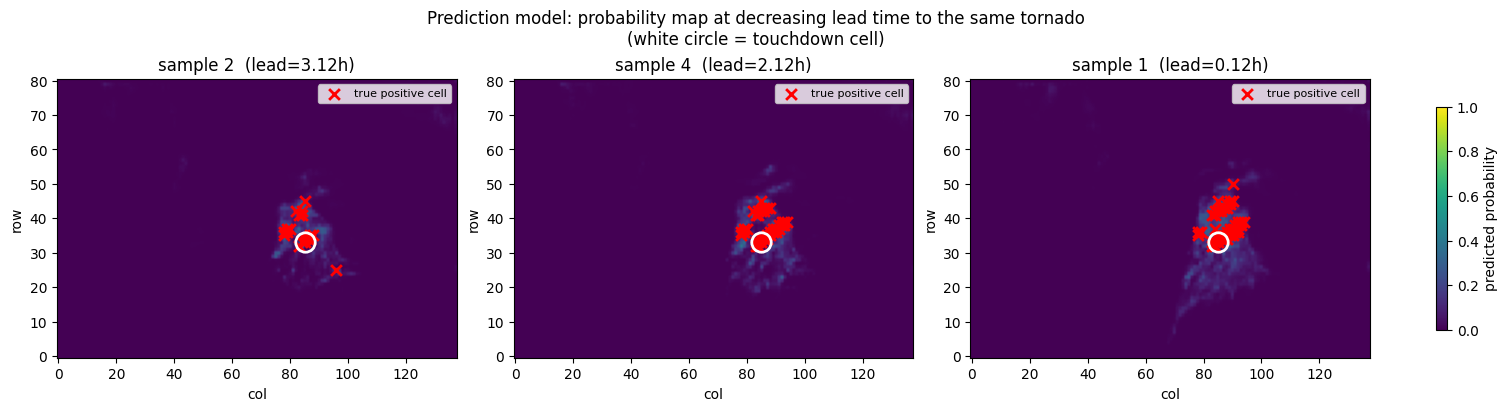

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im = None
for ax, (_, row_meta) in zip(axes, this_event.iterrows()):
    X, y = dataset[row_meta["sample"]]
    proba = predict_proba(model, X)
    _, im = plot_sample(
        proba, y,
        title=f"sample {row_meta['sample']}  (lead={row_meta['lead_hours_to_touchdown']:.2f}h)",
        ax=ax,
    )
    ax.plot(col, row, marker="o", markersize=14, markerfacecolor="none", markeredgecolor="white", markeredgewidth=2)

fig.colorbar(im, ax=axes.ravel().tolist(), label="predicted probability", shrink=0.8)
fig.suptitle("Prediction model: probability map at decreasing lead time to the same tornado\n(white circle = touchdown cell)")
plt.savefig("case_study_prediction_lead_times.png", dpi=150)
plt.show()

## Detection model: the same tornado, from radar

Pulled directly from the sibling `tornet` project's own already-executed
analysis (`tornet/notebooks/july_6th_result_analysis.ipynb`, cell 18) --
not re-run here, since that requires a separate environment and trained
weights outside this repo. These are that notebook's cached, saved
results:

| | |
|---|---|
| Sample | TorNet catalog `event_id 997130`, radar `KNQA` |
| Model | "no-MADIS" detection CNN |
| Radar frame used | first frame only, valid ~2021-12-11 01:35:30 UTC (~28 min *after* touchdown) |
| Predicted logit | 6.4960 |
| **Predicted probability** | **0.9985 (99.85%)** |
| True label | TOR (EF4) |

The detection model is looking at a direct radar signature of the
tornado essentially as it's happening, not inferring risk from
pre-storm atmospheric fields hours out -- a fundamentally easier,
more direct problem than prediction. The gap between 99.85% (detection,
near-real-time) and 19-61% (prediction, 2-3+ hours out, on a
6-sample model) isn't "prediction is bad" so much as it reflects that
difference in problem difficulty, compounded by the prediction model's
current pilot-scale training data.

Saved output figure from that notebook (copied here for reference):

![TorNet no-MADIS detection model output for this event](tornet_detection_case_study.png)

## Summary

- **Pipeline mechanics confirmed end-to-end**: for one real, documented
  EF4 tornado, HRRR features were correctly pulled and pooled onto the
  grid cell containing its touchdown point, the trained CNN produced a
  spatially coherent probability map centered on the true track, and
  those outputs can be lined up cleanly against an independent
  detection model's output for the same event.
- **Not an accuracy result.** The prediction model's probabilities are
  modest and don't behave monotonically with lead time -- both direct,
  expected consequences of training on 6 samples with an untuned
  `alpha`. A real accuracy claim needs a scaled-up training set, a
  train/val split, and probably a retuned/re-verified loss -- none of
  which this notebook attempts.
- **Next step**, per `CLAUDE.md`'s roadmap: resolve the HRRR-archive-
  availability-vs-training-period question and scale the training
  dataset past this single outbreak.